# M2-T04 — Train nnU-Net and compare the models
**Done when:** both models are scored on the **same validation set** with the **same metrics**, and the best one is chosen.

This notebook uses the team's own pieces, so the comparison is fair:

| What | Where it comes from |
|---|---|
| Data | the cleaned BraTS 2021 patients from M1-T04 (`processed/brats2021_trainval_v1.tar` on Drive), same as the baseline |
| Split | `qc/split_v1.csv` (train / val). Test patients are never touched |
| Metrics | `bmts.segmentation.training.metrics` (`region_scores`, `summarize`) = M2-T02 conventions |
| Baseline scores | the per-patient CSV written by the M2-T03 final evaluation (EXP-0001) |

**How to run:** Runtime → Change runtime type → **GPU**, fill the config cell, then Run all.
Training is long: if Colab disconnects, just Run all again — nnU-Net resumes from its last checkpoint on Drive.

## 0. Config

In [11]:
REPO_URL = "https://github.com/nhahub/NHA-5-187.git"
BRANCH   = "M2-T03-unet-baseline"      # has metrics.py + constants; switch to "main" once merged

BASE        = "/content/drive/MyDrive/BrainMRI_Data"
CLEANED_TAR = f"{BASE}/processed/brats2021_trainval_v1.tar"
SPLIT_CSV   = f"{BASE}/qc/split_v1.csv"
BASELINE_RUN_DIR = f"{BASE}/runs/EXP-0001_unet3d_baseline"     # M2-T03 outputs (best.pt, evaluation/...)
WORK_DIR    = f"{BASE}/runs/M2-T04_nnunet"                      # everything of this task is saved here

LOCAL_DIR   = "/content/nnunet_work"    # fast local disk (lost when the session ends)
PROCESSED   = "/content/processed/brats2021"

DATASET_ID, DATASET_NAME = 501, "BraTS2021"
CONFIG, FOLD = "3d_fullres", 0
# Baseline budget = 60 epochs x 200 steps = 12,000 steps. nnU-Net epoch = 250 steps, so 50 epochs = 12,500 steps (matched budget).
TRAINER    = "nnUNetTrainer_50epochs"
CHECKPOINT = "checkpoint_best.pth"     # use "checkpoint_best.pth" if training was stopped early

BASELINE_CSV = f"{BASELINE_RUN_DIR}/final_val_per_case.csv"    # set a path here only if the automatic search in section 9 fails

## 1. Drive, repo, packages

In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, json, re, glob, shutil, subprocess, time, math
from pathlib import Path
import numpy as np, pandas as pd, nibabel as nib

os.makedirs(WORK_DIR, exist_ok=True); os.makedirs(LOCAL_DIR, exist_ok=True)

if Path("/content/repo/.git").exists():
    !git -C /content/repo fetch -q origin && git -C /content/repo checkout -q {BRANCH} && git -C /content/repo pull -q origin {BRANCH}
else:
    !git clone -q -b {BRANCH} {REPO_URL} /content/repo
!git -C /content/repo log --oneline -1
!pip -q install nnunetv2 "monai>=1.4" mlflow nibabel
sys.path.insert(0, "/content/repo/src")

import torch
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

Mounted at /content/drive
82f208e (HEAD -> M2-T03-unet-baseline, origin/M2-T03-unet-baseline) M2-T03: 3D U-Net baseline training with MLflow logging, resume and final validation
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 M

## 2. Check the team's conventions (read the output once)
We reuse `REGIONS` and `region_scores` from the repo. In the repo `REGIONS` maps each region to its label values
(TC = labels 1,3 | WT = 1,2,3 | ET = 3), so the cleaned segmentations already use ET = 3 and we score nnU-Net with exactly the same label sets.

In [3]:
from bmts.common.constants import REGIONS
from bmts.segmentation.training.metrics import region_scores, summarize, METRICS
print("REGIONS:", REGIONS, "| METRICS:", METRICS)
assert set(REGIONS) == {"TC", "WT", "ET"} and isinstance(REGIONS, dict), "unexpected REGIONS format - tell me"

!grep -rniE "seg|label|REGIONS|== ?4|== ?1" /content/repo/src/bmts/data/datasets/brats.py | head -40

REGIONS: {'TC': (1, 3), 'WT': (1, 2, 3), 'ET': (3,)} | METRICS: ('dice', 'iou', 'sensitivity', 'precision', 'hd95')
4:    <processed_root>/<dataset>/<subject>/<timepoint>/{t1,t1ce,t2,flair,seg}.nii.gz
21:from bmts.common.constants import MODALITIES, SEG
40:    """Return one dict per (patient, timepoint): {"id", "t1", "t1ce", "t2", "flair", "seg"} file paths.
69:            files = {k: tp / f"{k}.nii.gz" for k in (*MODALITIES, SEG)}


## 3. Cleaned patients (same data as the baseline)

In [4]:
marker = Path("/content/processed/.trainval_ready")
if marker.exists():
    print("cleaned patients already on this disk")
elif Path(CLEANED_TAR).exists():
    print("restoring cleaned patients from Drive (about 10 min) ...")
    !mkdir -p /content/processed && tar -xf "{CLEANED_TAR}" -C /content/processed
    marker.touch()
else:
    raise FileNotFoundError(f"{CLEANED_TAR} not found. Run notebook 04_train_unet_baseline.ipynb section 3 once "
                            "(it cleans the patients and saves this archive) or ask the owner of M1-T04.")

CASES = {}
for subj in sorted(Path(PROCESSED).glob("BraTS2021_*")):
    tps = [d for d in subj.iterdir() if d.is_dir()]
    assert len(tps) == 1, (subj, tps)
    CASES[subj.name] = tps[0]
print(len(CASES), "cleaned patients; example:", next(iter(CASES.values())), os.listdir(next(iter(CASES.values()))))

restoring cleaned patients from Drive (about 10 min) ...
1063 cleaned patients; example: /content/processed/brats2021/BraTS2021_00000/0 ['t1ce.nii.gz', 'flair.nii.gz', 'seg.nii.gz', 't1.nii.gz', 't2.nii.gz']


## 4. Split: train / val from `split_v1.csv` (test is never used)

In [5]:
sp = pd.read_csv(SPLIT_CSV)
sp = sp[sp["dataset_source"].astype(str).str.lower() == "brats2021"]
locked = sp["lockbox"].astype(str).str.lower().isin(["true", "1"])
print("locked / test rows left out:", int(locked.sum()))
sp = sp[~locked]                                                     # never touch locked test patients
sp = sp.assign(case=sp["patient_key"].astype(str).str.split("|").str[-1], split_=sp["split"].astype(str).str.lower())

TRAIN_IDS = sorted(sp[sp.split_ == "train"].case)
VAL_IDS   = sorted(sp[sp.split_.isin(["val", "valid", "validation"])].case)
missing = [c for c in TRAIN_IDS + VAL_IDS if c not in CASES]
assert not missing, f"in split but not in cleaned data: {missing[:5]}"
assert not set(TRAIN_IDS) & set(VAL_IDS)
print("train:", len(TRAIN_IDS), "| val:", len(VAL_IDS), "| split values used:", sorted(sp.split_.unique()))

def to_case(x):
    x = str(x).split("|")[-1]
    return x if x in CASES else f"BraTS2021_{x}"

locked / test rows left out: 188
train: 875 | val: 188 | split values used: ['train', 'val']


## 5. Convert to nnU-Net format
Images are **symlinked** (no copy) as `_0000..._0003` = T1, T1ce, T2, FLAIR. Labels are copied as-is (the cleaned data already uses 0 bg, 1 NCR, 2 ED, 3 ET).
Only train + val patients are included.

In [6]:
from concurrent.futures import ThreadPoolExecutor

RAW, PRE, RES = f"{LOCAL_DIR}/nnUNet_raw", f"{LOCAL_DIR}/nnUNet_preprocessed", f"{WORK_DIR}/nnUNet_results"
for p in (RAW, PRE, RES): os.makedirs(p, exist_ok=True)
os.environ.update(nnUNet_raw=RAW, nnUNet_preprocessed=PRE, nnUNet_results=RES)

DS = f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
IMG_TR, LBL_TR = f"{RAW}/{DS}/imagesTr", f"{RAW}/{DS}/labelsTr"
os.makedirs(IMG_TR, exist_ok=True); os.makedirs(LBL_TR, exist_ok=True)
MODS = ["t1", "t1ce", "t2", "flair"]

ALL_IDS = TRAIN_IDS + VAL_IDS
u = np.unique(np.asarray(nib.load(CASES[ALL_IDS[0]] / "seg.nii.gz").dataobj))
print("label values in the first cleaned seg:", u)
assert set(u.tolist()) <= {0, 1, 2, 3}, "unexpected label values (expected 0-3 in the cleaned data) - tell me"

def convert(c):
    d = CASES[c]
    for i, m in enumerate(MODS):
        dst = f"{IMG_TR}/{c}_{i:04d}.nii.gz"
        if not os.path.lexists(dst): os.symlink(str(d / f"{m}.nii.gz"), dst)
    dst = f"{LBL_TR}/{c}.nii.gz"
    if not os.path.exists(dst):
        seg = nib.load(d / "seg.nii.gz")
        arr = np.asarray(seg.dataobj).astype(np.uint8)
        nib.save(nib.Nifti1Image(arr, seg.affine, seg.header), dst)

with ThreadPoolExecutor(8) as ex: list(ex.map(convert, ALL_IDS))

json.dump({"channel_names": {"0": "T1", "1": "T1ce", "2": "T2", "3": "FLAIR"},
           "labels": {"background": 0, "NCR": 1, "ED": 2, "ET": 3},
           "numTraining": len(ALL_IDS), "file_ending": ".nii.gz"},
          open(f"{RAW}/{DS}/dataset.json", "w"), indent=2)
print("converted", len(ALL_IDS), "patients ->", f"{RAW}/{DS}")

label values in the first cleaned seg: [0 1 2 3]
converted 1063 patients -> /content/nnunet_work/nnUNet_raw/Dataset501_BraTS2021


## 6. Plan + preprocess, then force the team's split

In [ ]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} -c {CONFIG} --verify_dataset_integrity

Fingerprint extraction...
Dataset501_BraTS2021
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Extracting dataset fingerprint: 100% 1063/1063 [18:54<00:00,  1.07s/it]
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [140. 171. 137.], 3d_lowres: [140, 171, 137]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'ba

In [ ]:
splits = [{"train": TRAIN_IDS, "val": VAL_IDS}]
json.dump(splits, open(f"{PRE}/{DS}/splits_final.json", "w"), indent=2)
json.dump(splits, open(f"{WORK_DIR}/splits_final.json", "w"), indent=2)
print("splits_final.json written (fold 0 = team split)")

splits_final.json written (fold 0 = team split)


## 7. Train nnU-Net
Checkpoints go to Drive (`WORK_DIR/nnUNet_results`). `--c` resumes after a disconnect: re-run sections 1, 3, 4, 5 (and 6 if
`/content` was wiped), then this cell. Likely several hours on a T4, so expect more than one session.

In [ ]:
!nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -tr {TRAINER} --c

2026-10-10 13:52:17.624661: train_loss -0.7572
2026-10-10 13:52:17.639680: val_loss -0.7898
2026-10-10 13:52:17.655852: Pseudo dice [np.float32(0.8751), np.float32(0.8993), np.float32(0.9244)]
2026-10-10 13:52:17.672806: Epoch time: 448.13 s
2026-10-10 13:52:17.690754: Yayy! New best EMA pseudo Dice: 0.8707000017166138
2026-10-10 13:52:25.512552: 
2026-10-10 13:52:25.516328: Epoch 47
2026-10-10 13:52:25.520301: Current learning rate: 0.00079
2026-10-10 13:59:19.035332: train_loss -0.764
2026-10-10 13:59:19.059497: val_loss -0.7867
2026-10-10 13:59:19.067259: Pseudo dice [np.float32(0.8682), np.float32(0.8854), np.float32(0.9173)]
2026-10-10 13:59:19.074768: Epoch time: 413.52 s
2026-10-10 13:59:19.088282: Yayy! New best EMA pseudo Dice: 0.8726999759674072
2026-10-10 13:59:27.716321: 
2026-10-10 13:59:27.720791: Epoch 48
2026-10-10 13:59:27.727329: Current learning rate: 0.00055
2026-10-10 14:06:31.948052: train_loss -0.7664
2026-10-10 14:06:31.970443: val_loss -0.7946
2026-10-10 14:06:

In [10]:
print(len(VAL_IDS), os.path.exists(IMG_TR))

188 True


## 8. Predict on the validation patients and score with the team's metrics

In [12]:
IMG_VAL, PRED = f"{LOCAL_DIR}/imagesVal", f"{WORK_DIR}/pred_nnunet_val"
os.makedirs(IMG_VAL, exist_ok=True); os.makedirs(PRED, exist_ok=True)
for c in VAL_IDS:
    for i in range(4):
        dst = f"{IMG_VAL}/{c}_{i:04d}.nii.gz"
        if not os.path.lexists(dst): os.symlink(f"{IMG_TR}/{c}_{i:04d}.nii.gz", dst)

In [13]:
!nnUNetv2_predict -i {IMG_VAL} -o {PRED} -d {DATASET_ID} -c {CONFIG} -f {FOLD} -tr {TRAINER} -chk {CHECKPOINT}


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 188 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 188 cases that I would like to predict

Predicting BraTS2021_00032:
perform_everything_on_device: True
100% 8/8 [00:10<00:00,  1.35s/it]
sending off prediction to background worker for resampling and export
done with BraTS2021_00032

Predicting BraTS2021_00059:
perform_everything_on_device: True
100% 8/8 [00:06<00:00,  1.26it/s]
sending off prediction to background worker for resampling and export
done with BraTS2021_00059

Predicting BraTS2021_00077:
perform_everythin

In [14]:
def to_regions(seg):
    """Label map -> (C, H, W, D) binary tensor in REGIONS order, using the repo's own label sets (REGIONS[r])."""
    return torch.from_numpy(np.stack([np.isin(seg, REGIONS[r]) for r in REGIONS])).float()

per_case_nn = {}
for k, c in enumerate(VAL_IDS):
    pr = nib.load(f"{PRED}/{c}.nii.gz"); gt = nib.load(f"{LBL_TR}/{c}.nii.gz")
    p, g = np.asarray(pr.dataobj).astype(np.uint8), np.asarray(gt.dataobj).astype(np.uint8)
    assert p.shape == g.shape, (c, p.shape, g.shape)
    per_case_nn[c] = region_scores(to_regions(p), to_regions(g), spacing=tuple(float(z) for z in gt.header.get_zooms()[:3]))
    if k % 25 == 0: print(k, "/", len(VAL_IDS))

flat = lambda sc: {f"{m}_{r}": sc[r][m] for r in REGIONS for m in METRICS}
pd.DataFrame([{"case": c, **flat(s)} for c, s in per_case_nn.items()]).to_csv(f"{WORK_DIR}/scores_nnunet_per_case.csv", index=False)
summary_nn = summarize([per_case_nn[c] for c in VAL_IDS])
print("nnU-Net mean Dice (TC/WT/ET avg):", round(summary_nn["mean_dice"], 4))

/usr/local/lib/python3.13/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.13/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


0 / 188
25 / 188
50 / 188
75 / 188
100 / 188
125 / 188
150 / 188
175 / 188
nnU-Net mean Dice (TC/WT/ET avg): 0.9078


## 9. Load the 3D U-Net baseline scores (M2-T03 final evaluation)
Looks for the per-patient CSV in the baseline run folder, then in the MLflow artifacts. Set `BASELINE_CSV` in the config if it
picks the wrong file. Column names like `dice_TC` or `TC_dice` are both understood.

In [16]:
def to_case(x):
    m = re.search(r"BraTS2021_\d+", str(x))
    return m.group(0) if m else str(x)
def find_baseline_csv():
    if BASELINE_CSV: return BASELINE_CSV
    hits = [p for p in glob.glob(f"{BASELINE_RUN_DIR}/**/*.csv", recursive=True)]
    hits = [p for p in hits if re.search(r"patient|per_?case|case", os.path.basename(p), re.I)] or hits
    if hits: return sorted(hits)[0]
    from mlflow.tracking import MlflowClient
    client = MlflowClient(tracking_uri=f"sqlite:///{BASE}/mlflow.db")
    exp = client.get_experiment_by_name("BrainMRI_3D_UNet")
    run = client.search_runs([exp.experiment_id], filter_string="tags.mlflow.runName = 'EXP-0001'",
                             order_by=["attributes.start_time DESC"], max_results=1)[0]
    d = client.download_artifacts(run.info.run_id, "evaluation", "/content/baseline_eval")
    hits = glob.glob(f"{d}/**/*.csv", recursive=True)
    assert hits, "no per-patient CSV found - ask the owner of M2-T03 where it is"
    return sorted(hits)[0]

csv_path = find_baseline_csv()
print("baseline per-patient scores:", csv_path)
bl = pd.read_csv(csv_path); print(bl.columns.tolist()); print(bl.head(2))

low = {c: c.lower() for c in bl.columns}
id_c = next((c for c in bl.columns if low[c] in ("case", "case_id", "patient", "patient_id", "subject", "subject_id", "id", "name")), bl.columns[0])
if "region" in low.values():                                         # long format -> wide
    rc = next(c for c in bl.columns if low[c] == "region")
    bl = bl.pivot(index=id_c, columns=rc, values=[m for m in METRICS if m in low.values()]).reset_index()
    bl.columns = [id_c if b == "" else f"{a}_{b}" for a, b in bl.columns]

colmap = {}
for c in bl.columns:
    m = next((x for x in METRICS if x in c.lower()), None)
    r = re.search(r"(?<![A-Za-z])(TC|WT|ET)(?![A-Za-z])", c, re.I)
    if m and r and c != id_c: colmap[(r.group(1).upper(), m)] = c
need = {(r, "dice") for r in REGIONS}
assert need <= set(colmap), f"could not find Dice columns for all regions in {bl.columns.tolist()} - send me the header"

per_case_bl = {}
for _, row in bl.iterrows():
    cid = to_case(row[id_c])
    per_case_bl[cid] = {r: {m: float(row[colmap[(r, m)]]) for m in METRICS if (r, m) in colmap} for r in REGIONS}
missing = [c for c in VAL_IDS if c not in per_case_bl]
assert not missing, f"baseline CSV lacks {len(missing)} validation patients, e.g. {missing[:3]}"
summary_bl = summarize([per_case_bl[c] for c in VAL_IDS])

# cross-check against the number MLflow logged at the end of M2-T03
try:
    from mlflow.tracking import MlflowClient
    client = MlflowClient(tracking_uri=f"sqlite:///{BASE}/mlflow.db")
    exp = client.get_experiment_by_name("BrainMRI_3D_UNet")
    run = client.search_runs([exp.experiment_id], filter_string="tags.mlflow.runName = 'EXP-0001'",
                             order_by=["attributes.start_time DESC"], max_results=1)[0]
    print("MLflow final_val_mean_dice:", run.data.metrics.get("final_val_mean_dice"), "| from CSV:", round(summary_bl["mean_dice"], 4))
except Exception as e:
    print("MLflow cross-check skipped:", e)

baseline per-patient scores: /content/drive/MyDrive/BrainMRI_Data/runs/EXP-0001_unet3d_baseline/final_val_per_case.csv
['case', 'TC_dice', 'TC_iou', 'TC_sensitivity', 'TC_precision', 'TC_hd95', 'WT_dice', 'WT_iou', 'WT_sensitivity', 'WT_precision', 'WT_hd95', 'ET_dice', 'ET_iou', 'ET_sensitivity', 'ET_precision', 'ET_hd95']
                           case   TC_dice    TC_iou  TC_sensitivity  \
0  brats2021__BraTS2021_00032/0  0.903403  0.823824        0.913162   
1  brats2021__BraTS2021_00059/0  0.839824  0.723876        0.865651   

   TC_precision    TC_hd95   WT_dice    WT_iou  WT_sensitivity  WT_precision  \
0      0.893850   4.123106  0.923525  0.857915        0.935297      0.912045   
1      0.815493  86.593880  0.851295  0.741092        0.842597      0.860176   

     WT_hd95   ET_dice    ET_iou  ET_sensitivity  ET_precision    ET_hd95  
0   3.000000  0.873010  0.774638        0.872223      0.873797   3.316625  
1  75.249573  0.893627  0.807708        0.945753      0.846946  77.

## 10. Compare and choose

,region,metric,3D U-Net,nnU-Net,NaN skipped (U-Net / nnU-Net)
0,TC,dice,0.7173,0.9171,0 / 0
1,TC,iou,0.5980,0.8674,0 / 0
2,TC,sensitivity,0.7406,0.9050,0 / 0
3,TC,precision,0.7923,0.9463,1 / 0
4,TC,hd95,16.1802,4.6011,1 / 0
5,WT,dice,0.8482,0.9346,0 / 0
6,WT,iou,0.7528,0.8821,0 / 0
7,WT,sensitivity,0.8421,0.9170,0 / 0
8,WT,precision,0.8864,0.9597,1 / 0
9,WT,hd95,18.8373,5.6196,1 / 0


mean Dice over TC/WT/ET -> 3D U-Net: 0.7646 | nnU-Net: 0.9078
paired Wilcoxon on per-patient mean Dice: p = 3.222e-31 | nnU-Net better on 97% of patients


/tmp/ipykernel_867/3647382394.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([[per_case_bl[c][r]["dice"] for c in VAL_IDS], [per_case_nn[c][r]["dice"] for c in VAL_IDS]], labels=["3D U-Net", "nnU-Net"])
/tmp/ipykernel_867/3647382394.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([[per_case_bl[c][r]["dice"] for c in VAL_IDS], [per_case_nn[c][r]["dice"] for c in VAL_IDS]], labels=["3D U-Net", "nnU-Net"])
/tmp/ipykernel_867/3647382394.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  a.boxplot([[per_case_bl[c][r]["dice"] for c in VAL_IDS], [per_case_nn[c][r]["dice"] for c in VAL_IDS]], 

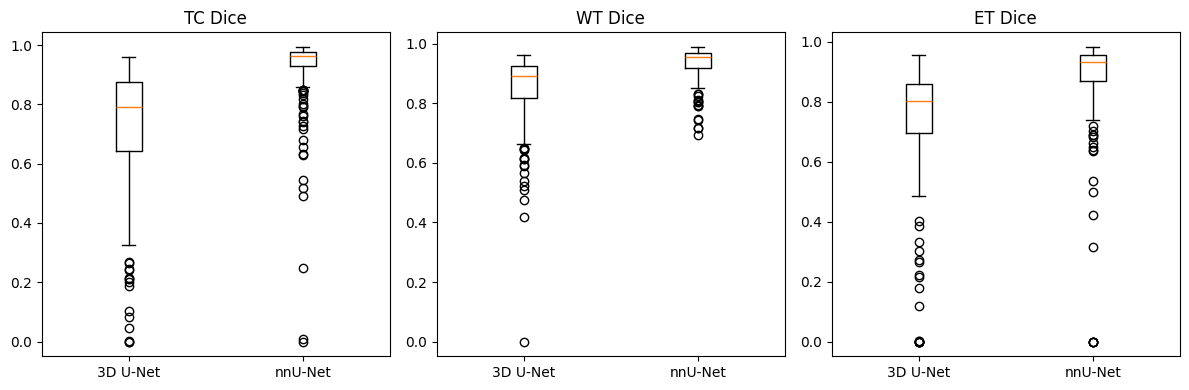

Best model by mean Dice: nnU-Net


In [17]:
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

rows = []
for r in REGIONS:
    for m in METRICS:
        if m in summary_bl[r] and m in summary_nn[r]:
            rows.append({"region": r, "metric": m,
                         "3D U-Net": summary_bl[r][m], "nnU-Net": summary_nn[r][m],
                         "NaN skipped (U-Net / nnU-Net)": f"{summary_bl[r][m + '_nan']} / {summary_nn[r][m + '_nan']}"})
table = pd.DataFrame(rows)
display(table.round(4))
print(f"mean Dice over TC/WT/ET -> 3D U-Net: {summary_bl['mean_dice']:.4f} | nnU-Net: {summary_nn['mean_dice']:.4f}")

mean_dice_case = lambda d: np.array([np.mean([d[c][r]["dice"] for r in REGIONS]) for c in VAL_IDS])
du, dn = mean_dice_case(per_case_bl), mean_dice_case(per_case_nn)
print(f"paired Wilcoxon on per-patient mean Dice: p = {wilcoxon(dn, du).pvalue:.4g} | nnU-Net better on {(dn > du).mean():.0%} of patients")

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for a, r in zip(ax, REGIONS):
    a.boxplot([[per_case_bl[c][r]["dice"] for c in VAL_IDS], [per_case_nn[c][r]["dice"] for c in VAL_IDS]], labels=["3D U-Net", "nnU-Net"])
    a.set_title(f"{r} Dice")
plt.tight_layout(); plt.savefig(f"{WORK_DIR}/comparison_dice.png", dpi=150); plt.show()

BEST = "nnU-Net" if summary_nn["mean_dice"] > summary_bl["mean_dice"] else "3D U-Net"
print("Best model by mean Dice:", BEST)
table.to_csv(f"{WORK_DIR}/comparison_table.csv", index=False)

## 11. Save the chosen model (hand-off to the Milestone 2 review task)

In [18]:
chosen = {
    "chosen_model": BEST,
    "selection_metric": "mean Dice over TC, WT, ET on all validation patients (split_v1)",
    "n_val_patients": len(VAL_IDS),
    "mean_dice": {"3D U-Net": summary_bl["mean_dice"], "nnU-Net": summary_nn["mean_dice"]},
    "unet3d": {"experiment": "EXP-0001", "weights": f"{BASELINE_RUN_DIR}/best.pt", "budget": "60 epochs x 200 steps"},
    "nnunet": {"dataset": DS, "configuration": CONFIG, "fold": FOLD, "trainer": TRAINER, "checkpoint": CHECKPOINT,
               "results_dir": f"{RES}/{DS}/{TRAINER}__nnUNetPlans__{CONFIG}"},
    "splits_file": f"{WORK_DIR}/splits_final.json",
}
json.dump(chosen, open(f"{WORK_DIR}/chosen_model.json", "w"), indent=2)
print(json.dumps(chosen, indent=2))

{
  "chosen_model": "nnU-Net",
  "selection_metric": "mean Dice over TC, WT, ET on all validation patients (split_v1)",
  "n_val_patients": 188,
  "mean_dice": {
    "3D U-Net": 0.7645918875907934,
    "nnU-Net": 0.9078128388140568
  },
  "unet3d": {
    "experiment": "EXP-0001",
    "weights": "/content/drive/MyDrive/BrainMRI_Data/runs/EXP-0001_unet3d_baseline/best.pt",
    "budget": "60 epochs x 200 steps"
  },
  "nnunet": {
    "dataset": "Dataset501_BraTS2021",
    "configuration": "3d_fullres",
    "fold": 0,
    "trainer": "nnUNetTrainer_50epochs",
    "checkpoint": "checkpoint_best.pth",
    "results_dir": "/content/drive/MyDrive/BrainMRI_Data/runs/M2-T04_nnunet/nnUNet_results/Dataset501_BraTS2021/nnUNetTrainer_50epochs__nnUNetPlans__3d_fullres"
  },
  "splits_file": "/content/drive/MyDrive/BrainMRI_Data/runs/M2-T04_nnunet/splits_final.json"
}


## 12. Wrap-up
- [ ] Commit this notebook + `chosen_model.json` + `comparison_table.csv` + `comparison_dice.png` on a branch for M2-T04 (e.g. `M2-T04-nnunet`) and open a PR.
- [ ] In the Notion task: paste the comparison table, the chosen model, and the training budgets (baseline 60 epochs x 200 steps; nnU-Net 50 epochs x 250 steps).
- [ ] Notes for the report: the baseline's `best.pt` was picked using the first 40 validation patients; nnU-Net uses its final checkpoint; nnU-Net predictions use its default mirroring TTA, the baseline uses sliding windows without TTA.
- [ ] Set **Status** and **Completed by**, then tell the owner of "Milestone 2 review: save the chosen model" that the outputs are in `WORK_DIR`.